# What is about ?

**Briefly:** visualization via  dimensional-reductions (pca, umap, tsne,...) are presented for datasets of MoA kaggle competition. The idea was to look for some clusters which often show up 
in genes expressions dataset (clusters corresponds for example to different cell-types).

Unfortunately the result seems to be NEGATIVE - there seems to be no clear  cluster structure show ups at glance in that dataset.


It might not be a surpise since rows of the data are drugs not cells/tissues. 

The only thing we observe some clustering seeing by LLE method. Clusters more or less   corresponds to  cp_time feature.
Which is natural, since drug use duration should affect strongly the viability and genes expressions. 
One may try to use LLE as additional feature. 


**Biological context:**
772 out of 876 features at MoA competition are said to be "gene expressions". 
Which biologically means how "hard" particular gene is working in the particular cell (or group of cells).
Note that all cells in the ogranism have the same genes, and one cell differs from another only by these gene expressions.
Currently much is known  what genes are expressed in partcilar cell types. 
For a random example - "KIT"-gene is highly expressed in must/stem cells https://en.wikipedia.org/wiki/KIT_(gene) 

To summarize: "gene expressions" give a kind of a "portrait" of a cell and bioinformaticians
are working how to extract as much information as possible from these "portraits" and further use it for disease and drug studies. 


Starting from around 2014  next-generation sequencing (NGS) technologies 
https://en.wikipedia.org/wiki/Single_cell_sequencing
provided huge amounts of these  "portraits" (datasets) for various cells from various organisms. 

Some examples of such datasets and information is available at kaggle also:
https://www.kaggle.com/chrispr/single-cell-rna-seq-from-stoeckius-et-al-2017
Some general tutorial: 
https://www.kaggle.com/usharengaraju/single-cell-rna-sequencing

We follow:
https://www.kaggle.com/alexandervc/dim-reduction-and-plots-scrnaseq-nestorova16


PS

It might be unfortune that genes names are anonimized in the MoA competition.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lish-moa/train_features.csv
/kaggle/input/lish-moa/test_features.csv
/kaggle/input/lish-moa/train_targets_nonscored.csv
/kaggle/input/lish-moa/sample_submission.csv
/kaggle/input/lish-moa/train_targets_scored.csv


# Load data

In [2]:
import time 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/lish-moa/train_features.csv',index_col = 0)  
df

,cp_type,cp_time,cp_dose,g-0,g-1,g-2,g-3,g-4,g-5,g-6,...,c-90,c-91,c-92,c-93,c-94,c-95,c-96,c-97,c-98,c-99
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,trt_cp,24,D1,1.0620,0.5577,-0.2479,-0.6208,-0.1944,-1.0120,-1.0220,...,0.2862,0.2584,0.8076,0.5523,-0.1912,0.6584,-0.3981,0.2139,0.3801,0.4176
id_000779bfc,trt_cp,72,D1,0.0743,0.4087,0.2991,0.0604,1.0190,0.5207,0.2341,...,-0.4265,0.7543,0.4708,0.0230,0.2957,0.4899,0.1522,0.1241,0.6077,0.7371
id_000a6266a,trt_cp,48,D1,0.6280,0.5817,1.5540,-0.0764,-0.0323,1.2390,0.1715,...,-0.7250,-0.6297,0.6103,0.0223,-1.3240,-0.3174,-0.6417,-0.2187,-1.4080,0.6931
id_0015fd391,trt_cp,48,D1,-0.5138,-0.2491,-0.2656,0.5288,4.0620,-0.8095,-1.9590,...,-2.0990,-0.6441,-5.6300,-1.3780,-0.8632,-1.2880,-1.6210,-0.8784,-0.3876,-0.8154
id_001626bd3,trt_cp,72,D2,-0.3254,-0.4009,0.9700,0.6919,1.4180,-0.8244,-0.2800,...,0.0042,0.0048,0.6670,1.0690,0.5523,-0.3031,0.1094,0.2885,-0.3786,0.7125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,trt_cp,24,D2,0.1394,-0.0636,-0.1112,-0.5080,-0.4713,0.7201,0.5773,...,0.1969,0.0262,-0.8121,0.3434,0.5372,-0.3246,0.0631,0.9171,0.5258,0.4680
id_fffb70c0c,trt_cp,24,D2,-1.3260,0.3478,-0.3743,0.9905,-0.7178,0.6621,-0.2252,...,0.4286,0.4426,0.0423,-0.3195,-0.8086,-0.9798,-0.2084,-0.1224,-0.2715,0.3689
id_fffc1c3f4,ctl_vehicle,48,D2,0.3942,0.3756,0.3109,-0.7389,0.5505,-0.0159,-0.2541,...,0.5409,0.3755,0.7343,0.2807,0.4116,0.6422,0.2256,0.7592,0.6656,0.3808


In [4]:
y = pd.read_csv('/kaggle/input/lish-moa/train_targets_nonscored.csv',index_col = 0 )
y

,abc_transporter_expression_enhancer,abl_inhibitor,ace_inhibitor,acetylcholine_release_enhancer,adenosine_deaminase_inhibitor,adenosine_kinase_inhibitor,adenylyl_cyclase_inhibitor,age_inhibitor,alcohol_dehydrogenase_inhibitor,aldehyde_dehydrogenase_activator,...,ve-cadherin_antagonist,vesicular_monoamine_transporter_inhibitor,vitamin_k_antagonist,voltage-gated_calcium_channel_ligand,voltage-gated_potassium_channel_activator,voltage-gated_sodium_channel_blocker,wdr5_mll_interaction_inhibitor,wnt_agonist,xanthine_oxidase_inhibitor,xiap_inhibitor
sig_id,,,,,,,,,,,,,,,,,,,,,
id_000644bb2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000779bfc,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_000a6266a,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_0015fd391,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_001626bd3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
id_fffb1ceed,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffb70c0c,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
id_fffc1c3f4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
mode_which_part_to_process = 'full'
if mode_which_part_to_process == 'full':
    # consider only gene expression part 
    X = df[[c for c in df.columns if ('c-' in c) or ('g-' in c)]].values
if mode_which_part_to_process == 'genes':
    # consider only gene expression part 
    X = df[[c for c in df.columns if 'g-' in c]].values
if mode_which_part_to_process == 'c':
    # consider only gene expression part 
    X = df[[c for c in df.columns if 'c-' in c]].values

X_original_save = X.copy()
print(X.shape)

y_sum = y.sum(axis = 1)
df['y_sum']=y_sum
print(y_sum.shape)
y_sum.value_counts()



(23814, 872)
(23814,)


0    19224
1     4282
2      247
3       36
4       13
7        6
5        6
dtype: int64

# PCA plots

3.2651193141937256 secs passed for PCA


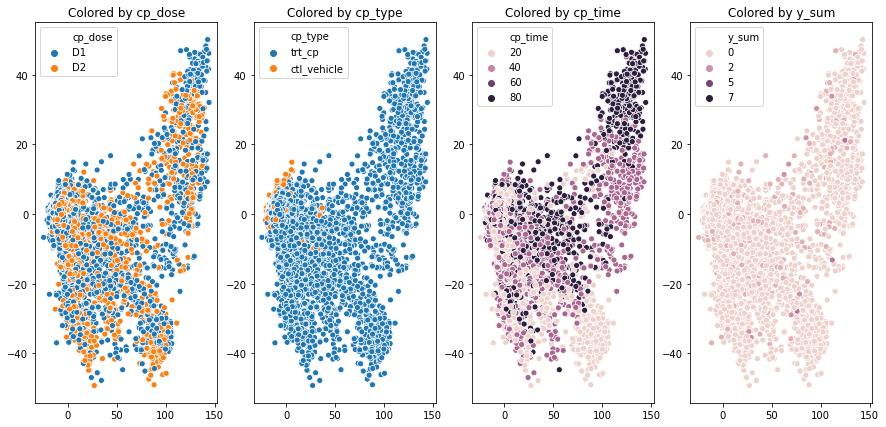

Text(0.5, 1.0, 'explained variance')

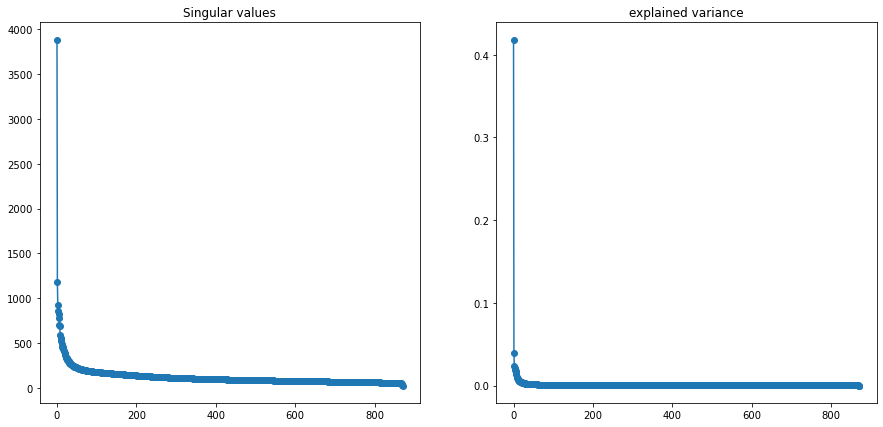

In [6]:
from sklearn.decomposition import PCA
import time 
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA()
t0 = time.time()
r = pca.fit_transform(X.copy())
print(time.time()-t0, 'secs passed for PCA')


fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time', 'y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    sns.scatterplot(x=r[:,0], y=r[:,1] , hue = df[f]  )
    plt.title('Colored by '+f)
plt.show()

fig = plt.figure(figsize = (15,7) )
fig.add_subplot(1, 2, 1) 
plt.plot(pca.singular_values_,'o-')
plt.title('Singular values')
fig.add_subplot(1, 2, 2) 
plt.plot(pca.explained_variance_ratio_,'o-')
plt.title('explained variance')

# UMAP plots

/opt/conda/lib/python3.7/site-packages/umap/nndescent.py:92: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see http://numba.pydata.org/numba-doc/latest/user/parallel.html#diagnostics for help.

File "../../opt/conda/lib/python3.7/site-packages/umap/utils.py", line 451:
@numba.njit(parallel=True)
def build_candidates(
^

  current_graph, n_vertices, n_neighbors, max_candidates, rng_state


56.837469816207886 secs passed for umap


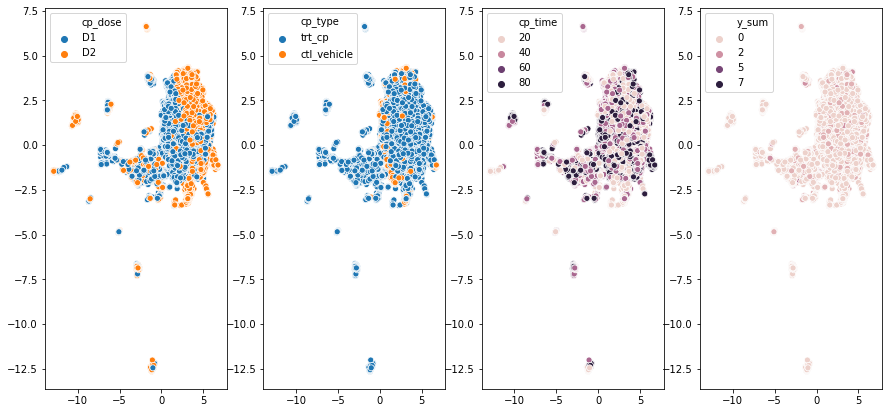

In [7]:
import umap

t0 = time.time()
r = umap.UMAP().fit_transform(X.copy())
print(time.time()-t0, 'secs passed for umap')


fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time','y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    sns.scatterplot(x=r[:,0], y=r[:,1] , hue = df[f]  )
plt.show()

# Visualize data by various dimensional reduction methods

## Fast methods

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:70: FutureWarning: Pass n_neighbors=10, n_components=2 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  FutureWarning)


PCA: 3.2 sec
umap: 51 sec
ICA: 3.4 sec
FA: 2.4 sec
Got Exception NMF
RandProj: 0.23 sec
RandTrees: 2.4 sec


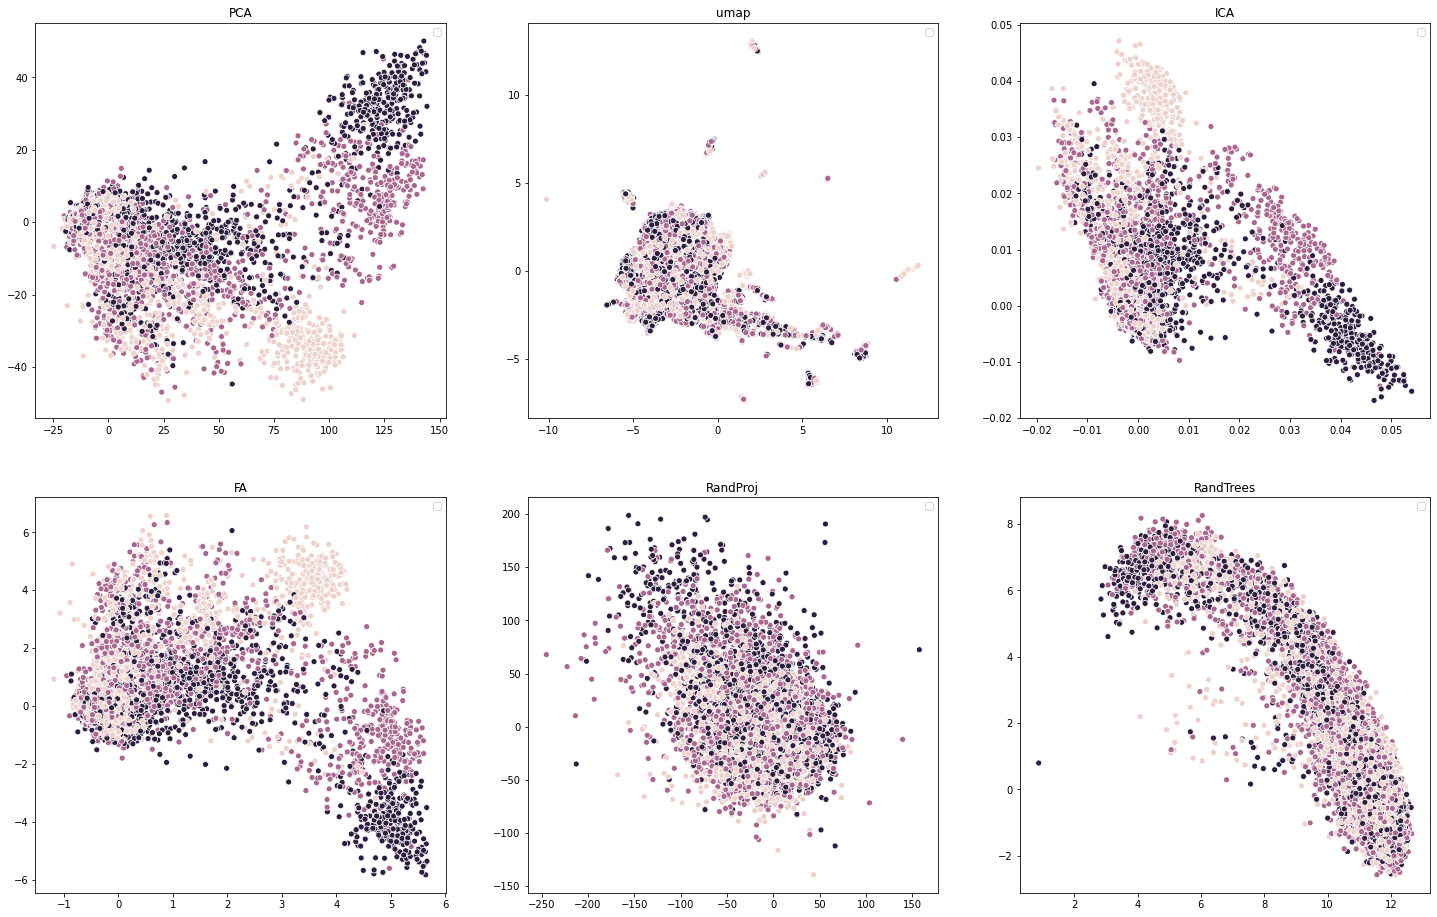

In [8]:
# Based on: 
# https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html#sphx-glr-auto-examples-manifold-plot-compare-methods-py
# See also:
# https://scikit-learn.org/stable/auto_examples/manifold/plot_lle_digits.html#



# To speed-up reduce dimensions by PCA first
X_save = X.copy( )
#r = pca.fit_transform(X)
#X = r[:1000,:20]



import umap 
from sklearn import manifold
from sklearn.decomposition import PCA
from sklearn.decomposition import FactorAnalysis
from sklearn.decomposition import NMF
from sklearn.decomposition import FastICA
from sklearn.decomposition import FactorAnalysis
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import RandomTreesEmbedding
from sklearn.random_projection import SparseRandomProjection
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.pipeline import make_pipeline
from sklearn.decomposition import TruncatedSVD


from collections import OrderedDict
from functools import partial
from matplotlib.ticker import NullFormatter


n_neighbors = 10
n_components = 2
# Set-up manifold methods
LLE = partial(manifold.LocallyLinearEmbedding,
              n_neighbors, n_components, eigen_solver='auto')

methods = OrderedDict()
methods['PCA'] = PCA()
methods['umap'] = umap.UMAP(n_components = n_components)
methods['t-SNE'] = manifold.TSNE(n_components=n_components, init='pca', random_state=0)
methods['ICA'] = FastICA(n_components=n_components,         random_state=0)
methods['FA'] = FactorAnalysis(n_components=n_components, random_state=0)
methods['LLE'] = LLE(method='standard')
methods['Modified LLE'] = LLE(method='modified')
methods['Isomap'] = manifold.Isomap(n_neighbors, n_components)
methods['MDS'] = manifold.MDS(n_components, max_iter=100, n_init=1)
methods['SE'] = manifold.SpectralEmbedding(n_components=n_components,
                                           n_neighbors=n_neighbors)
methods['NMF'] = NMF(n_components=n_components,  init='random', random_state=0) 
methods['RandProj'] = SparseRandomProjection(n_components=n_components, random_state=42)

rand_trees_embed = make_pipeline(RandomTreesEmbedding(n_estimators=200, random_state=0, max_depth=5), TruncatedSVD(n_components=n_components) )
methods['RandTrees'] = rand_trees_embed
methods['LatDirAll'] = LatentDirichletAllocation(n_components=n_components,  random_state=0)
methods['LTSA'] = LLE(method='ltsa') 
methods['Hessian LLE'] = LLE(method='hessian') 

list_fast_methods = ['PCA','umap','FA', 'ICA','NMF','RandProj','RandTrees']
list_slow_methods = ['t-SNE','LLE','Modified LLE','Isomap','MDS','SE','LatDirAll','LTSA','Hessian LLE']

# transformer = NeighborhoodComponentsAnalysis(init='random',  n_components=2, random_state=0) # Cannot be applied since supervised - requires y 
# methods['LinDisA'] = LinearDiscriminantAnalysis(n_components=n_components)# Cannot be applied since supervised - requires y 


# Create figure
fig = plt.figure(figsize=(25, 16))

# Plot results
c = 0
for i, (label, method) in enumerate(methods.items()):
    if label not in  list_fast_methods :
        continue
        
    t0 = time.time()
    try:
        r = method.fit_transform(X.copy())
    except:
        print('Got Exception', label )
        continue 
    t1 = time.time()
    print("%s: %.2g sec" % (label, t1 - t0))
    c+=1
    fig.add_subplot(2, 3 , c) 
    sns.scatterplot(x=r[:,0], y=r[:,1],hue =  df['cp_time'])
    plt.title(label )
    plt.legend('')

plt.show()
X = X_save.copy()


# Slow methods 

to speed up we cut X to smaller size 

PCA: 0.011 sec
umap: 18 sec
t-SNE: 39 sec
ICA: 0.026 sec


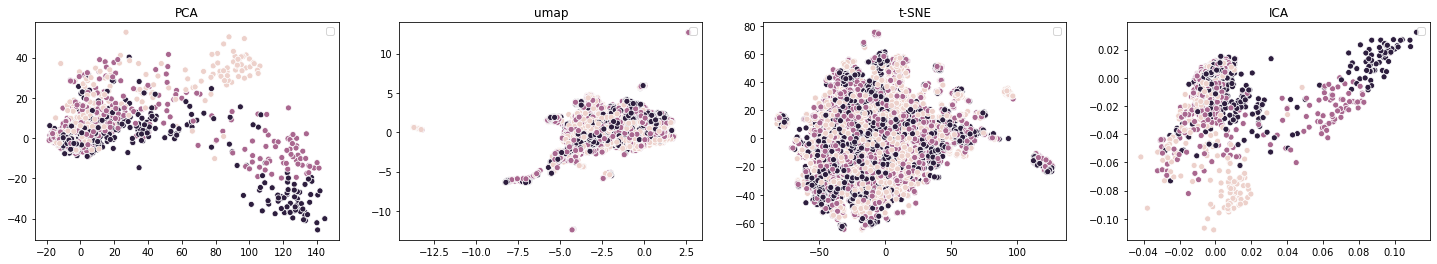

FA: 0.025 sec
LLE: 19 sec
Modified LLE: 20 sec
Isomap: 25 sec


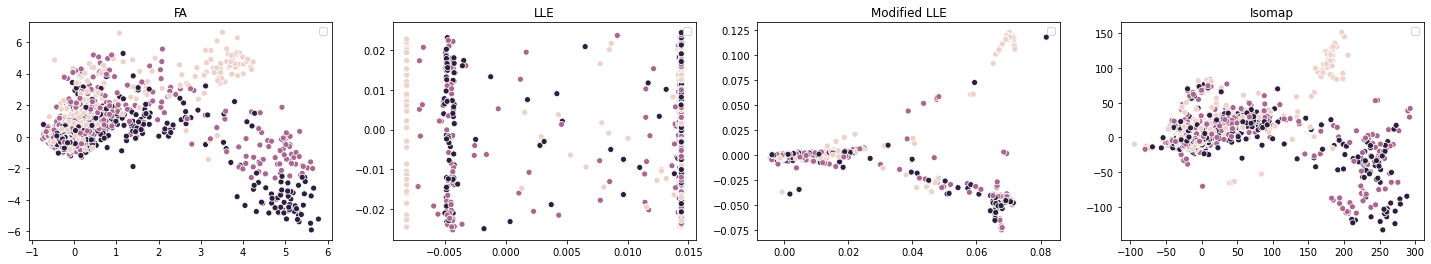

MDS: 56 sec
SE: 22 sec
Got Exception NMF
RandProj: 0.0028 sec
RandTrees: 0.61 sec


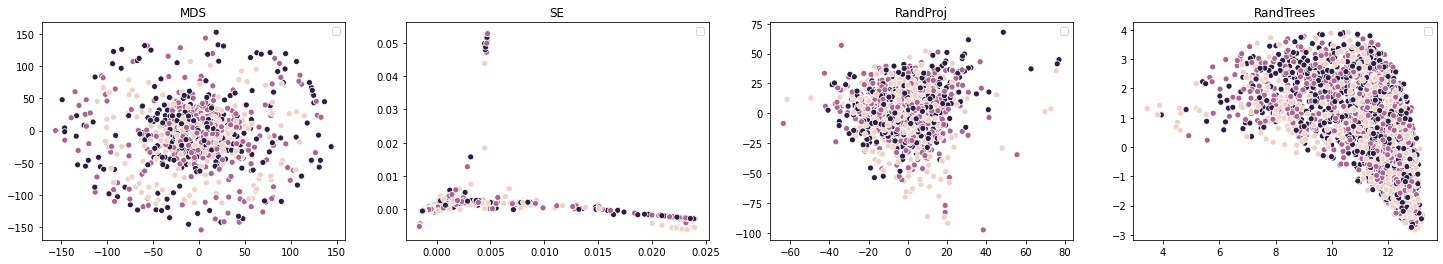

Got Exception LatDirAll


/opt/conda/lib/python3.7/site-packages/scipy/sparse/linalg/eigen/arpack/arpack.py:937: LinAlgWarning: Diagonal number 5 is exactly zero. Singular matrix.
  self.M_lu = lu_factor(M)


LTSA: 5.7 sec
Got Exception Hessian LLE


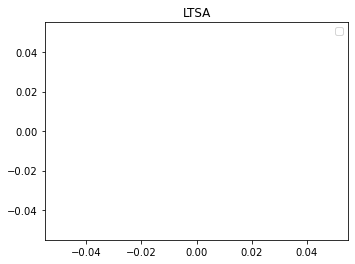

In [9]:
# To speed-up reduce dimensions by PCA first and cut the size
X_save = X.copy( )
r = pca.fit_transform(X)
i_cut = 5000
X = r[:i_cut,:50]


list_slow_methods = ['t-SNE','LLE','Modified LLE','Isomap','MDS','SE','LatDirAll','LTSA','Hessian LLE']

# transformer = NeighborhoodComponentsAnalysis(init='random',  n_components=2, random_state=0) # Cannot be applied since supervised - requires y 
# methods['LinDisA'] = LinearDiscriminantAnalysis(n_components=n_components)# Cannot be applied since supervised - requires y 


# Create figure
fig = plt.figure(figsize=(25, 4))

# Plot results
c = 0
for i, (label, method) in enumerate(methods.items()):
    #if label not in list_slow_methods: # list_fast_methods :
    #    continue
        
    t0 = time.time()
    try:
        r = method.fit_transform(X.copy())
    except:
        print('Got Exception', label )
        continue 
    t1 = time.time()
    print("%s: %.2g sec" % (label, t1 - t0))
    c+=1
    fig.add_subplot(1, 4 , c) 
    sns.scatterplot(x=r[:,0], y=r[:,1],hue =  df['cp_time'][:i_cut])
    plt.title(label )
    plt.legend('')
    if c%4 == 0:
        c = 0
        plt.show()
        fig = plt.figure(figsize=(25, 4))
        
    

plt.show()
X = X_save.copy()


In [10]:
X_save.shape

(23814, 872)

# LLE 

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:70: FutureWarning: Pass n_neighbors=10, n_components=2 as keyword args. From version 0.25 passing these as positional arguments will result in an error
  FutureWarning)


LLE: 19 sec


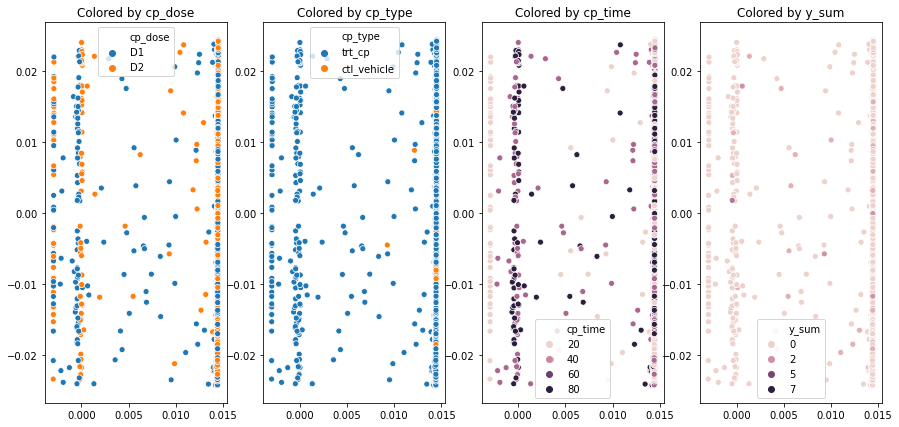

In [11]:
from sklearn.decomposition import PCA
import time 
import matplotlib.pyplot as plt
import seaborn as sns

# Preliminary reduce X to speed up:
r = pca.fit_transform(X.copy())
i_cut = 5000
r = r[:i_cut,:50]


n_neighbors = 10
n_components = 2
method = manifold.LocallyLinearEmbedding(n_neighbors, n_components, eigen_solver='auto', method='standard')
t0 = time.time()
r = method.fit_transform(r)
t1 = time.time()
print("%s: %.2g sec" % ('LLE', t1 - t0))

fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time', 'y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    sns.scatterplot(x=r[:,0], y=r[:,1] , hue = df[f][:i_cut]  )
    plt.title('Colored by '+f)
plt.show()


12.909974575042725 seconds passed


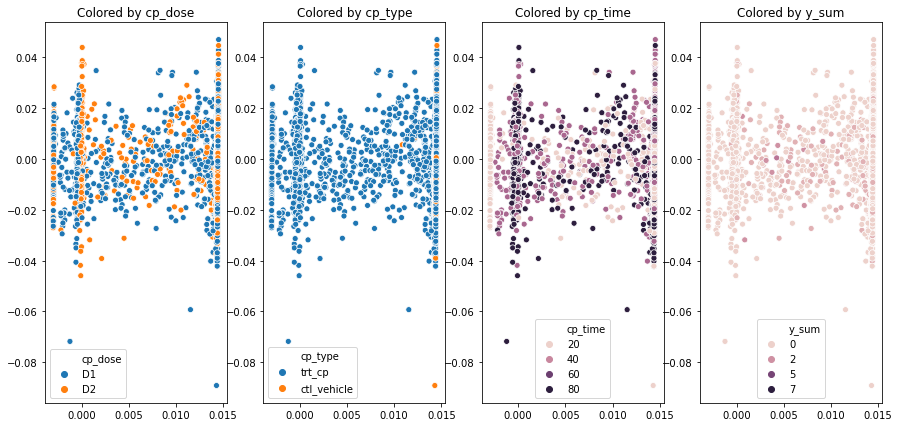

In [12]:
# Apply transform to full dataset 

r = pca.transform(X.copy() )
r = r[:,:50]

t0 = time.time()
r = method.transform(r)
print(time.time()-t0,'seconds passed')

fig = plt.figure(figsize = (15,7) )
c = 0
for f in ['cp_dose', 'cp_type','cp_time', 'y_sum']:
    c+=1; fig.add_subplot(1, 4 , c) 
    sns.scatterplot(x=r[:,0], y=r[:,1] , hue = df[f]  )
    plt.title('Colored by '+f)
plt.show()


In [13]:
df[f].value_counts() # strange that seaborn plots only 0,2,5,7 values

0    19224
1     4282
2      247
3       36
4       13
7        6
5        6
Name: y_sum, dtype: int64